# Time Series Classification on LSST — Setting 1: Adapting a Foundation Model

**Romain Tavenard — Deep Learning for Time Series, 2026**

---

| | |
|---|---|
| **Dataset** | LSST (PLAsTiCC) — 14 classes, (N, T=36, C=6) |
| **Setting** | 1 — Adapt a pre-trained foundation model |
| **Baseline** | InceptionTime (from scratch) |
| **Competitor** | MOMENT-1-large + ensemble (InceptionTime×5, PatchTST, Hydra+ROCKET) |
| **GitHub** | https://github.com/coulzie031/DeepLearningForTimeSeries |

## Outline
1. [Colab Setup](#1-colab-setup)
2. [Dataset & Problem](#2-dataset--problem)
3. [Preprocessing Pipeline](#3-preprocessing-pipeline)
4. [Baseline — InceptionTime (from scratch)](#4-baseline--inceptiontime-from-scratch)
5. [Setting 1 — MOMENT Foundation Model](#5-setting-1--moment-foundation-model)
6. [Ensemble Pipeline (Best Score)](#6-ensemble-pipeline-best-score)
7. [Results & Analysis](#7-results--analysis)
8. [Conclusion](#8-conclusion)

---
## 1. Colab Setup

This notebook runs **locally** and on **Google Colab** (GPU recommended).

In [1]:
import os, sys, subprocess

IN_COLAB = 'google.colab' in sys.modules
print(f'Running in Colab: {IN_COLAB}')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    REPO_URL  = 'https://github.com/coulzie031/DeepLearningForTimeSeries.git'
    REPO_DIR  = '/content/lsst'
    DRIVE_DIR = '/content/drive/MyDrive/lsst_results'

    if not os.path.exists(REPO_DIR):
        subprocess.run(['git', 'clone', REPO_URL, REPO_DIR])
    else:
        subprocess.run(['git', '-C', REPO_DIR, 'pull'])
    os.chdir(REPO_DIR)
    sys.path.insert(0, REPO_DIR)

    os.makedirs(DRIVE_DIR, exist_ok=True)
    if not os.path.exists(f'{REPO_DIR}/results'):
        os.symlink(DRIVE_DIR, f'{REPO_DIR}/results')

    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'momentfm', '--no-deps'])
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'huggingface_hub', 'transformers'])
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'sktime', 'aeon'])
    print('Dependencies installed.')

else:
    ROOT = os.path.abspath('.')
    if ROOT not in sys.path:
        sys.path.insert(0, ROOT)
    DRIVE_DIR = 'results'
    print(f'Local mode — ROOT: {ROOT}')

Running in Colab: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dependencies installed.


In [2]:
import math, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore')

from data.lsst_dataset import (
    load_lsst, preprocess, get_dataloaders,
    compute_class_weights, LSSTPatchDataset
)
from models.inception_time import InceptionTime
from models.moment_classifier import MOMENTClassifier, PatchTSTClassifier
from utils import (
    seed_everything, EarlyStopping, eval_epoch,
    compute_metrics, get_embeddings, save_logs, FocalLoss
)

seed_everything(42)
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP  = (DEVICE.type == 'cuda')
RD       = 'results'
os.makedirs(RD, exist_ok=True)
NUM_CLASSES = 14
N_CHANNELS  = 6

print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'AMP    : {USE_AMP}')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
AMP    : True


---
## 2. Dataset & Problem

### LSST / PLAsTiCC

Each sample is the **light curve** of an astronomical object: its brightness measured at 36 epochs
through 6 photometric filters (passbands u, g, r, i, z, y).

| Property | Value |
|----------|-------|
| Shape | `(N, T=36, C=6)` |
| Train / Test | 2,459 / 2,466 |
| Classes | 14 (supernovae, variable stars, AGN…) |
| Challenge 1 | Sparse observations → **NaN values** |
| Challenge 2 | Extreme **imbalance** (class 53: only 7 train samples!) |

In [3]:
X_train_raw, y_train, X_test_raw, y_test, le = load_lsst()
CLASS_NAMES  = [str(c) for c in le.classes_]
PASSBAND     = ['u', 'g', 'r', 'i', 'z', 'y']
counts_train = Counter(y_train)
imb_ratio    = max(counts_train.values()) / min(counts_train.values())
print(f'\nImbalance ratio: {imb_ratio:.0f}:1')
print(f'Overall NaN rate (train): {np.isnan(X_train_raw).mean()*100:.1f}%')

  LSST loaded — train: (2459, 36, 6), test: (2466, 36, 6)
  Shape: (N, T=36, C=6)
  Classes: ['15', '16', '42', '52', '53', '6', '62', '64', '65', '67', '88', '90', '92', '95']
  NaN rate (train): 0.0%

Imbalance ratio: 111:1
Overall NaN rate (train): 0.0%


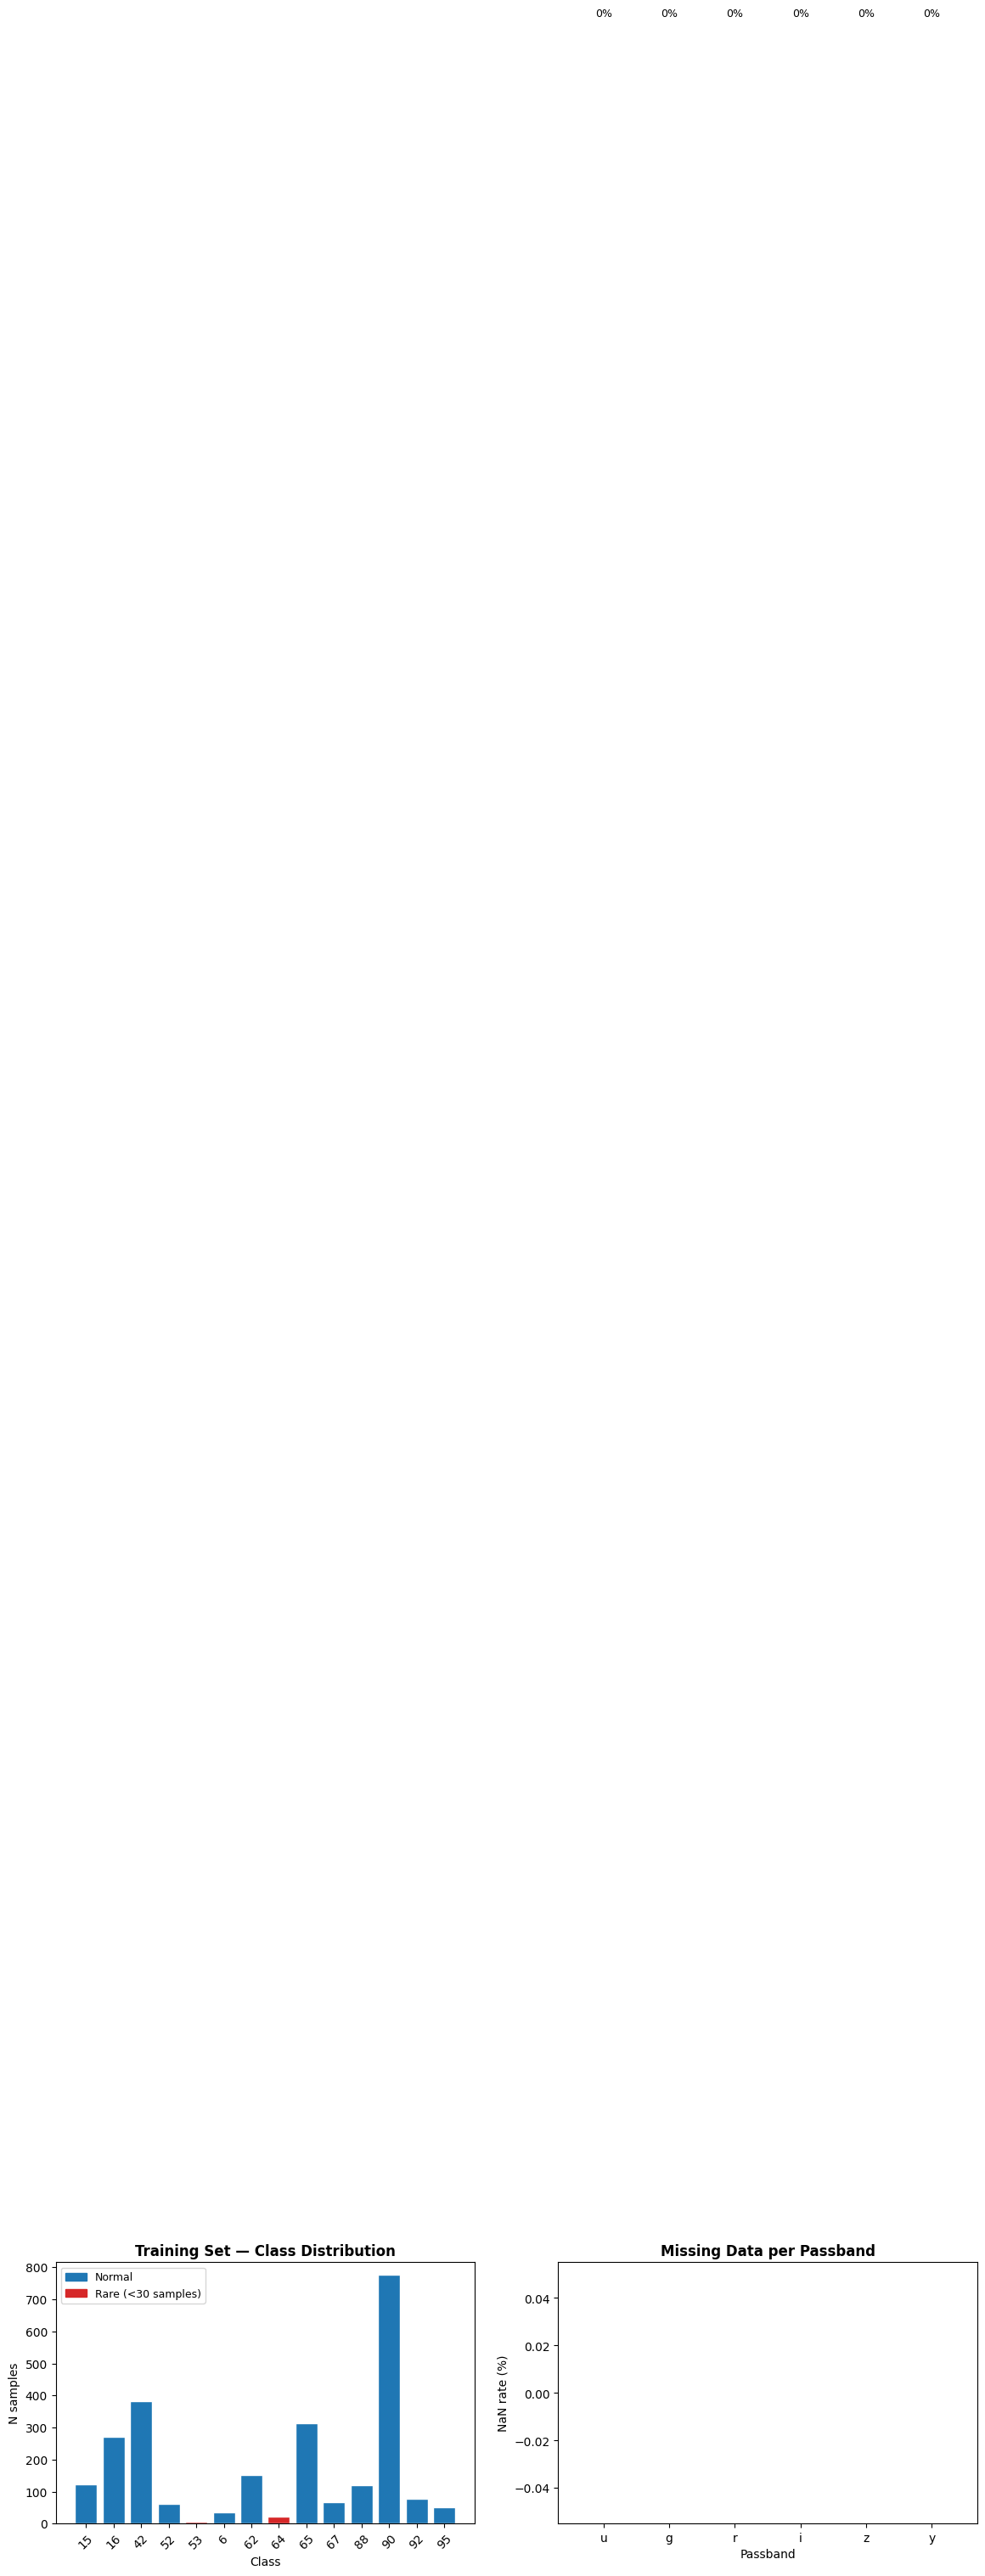

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class distribution
ax = axes[0]
ns     = [counts_train[i] for i in range(NUM_CLASSES)]
colors = ['#d62728' if n < 30 else '#1f77b4' for n in ns]
ax.bar(CLASS_NAMES, ns, color=colors, edgecolor='white')
ax.set_xlabel('Class'); ax.set_ylabel('N samples')
ax.set_title('Training Set — Class Distribution', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend(handles=[
    mpatches.Patch(color='#1f77b4', label='Normal'),
    mpatches.Patch(color='#d62728', label='Rare (<30 samples)'),
], fontsize=9)

# NaN rate per passband
ax2 = axes[1]
nan_r = np.isnan(X_train_raw).mean(axis=(0,1)) * 100
ax2.bar(PASSBAND, nan_r, color='#ff7f0e')
ax2.set_xlabel('Passband'); ax2.set_ylabel('NaN rate (%)')
ax2.set_title('Missing Data per Passband', fontweight='bold')
for b, v in zip(ax2.patches, nan_r):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.0f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{RD}/fig_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

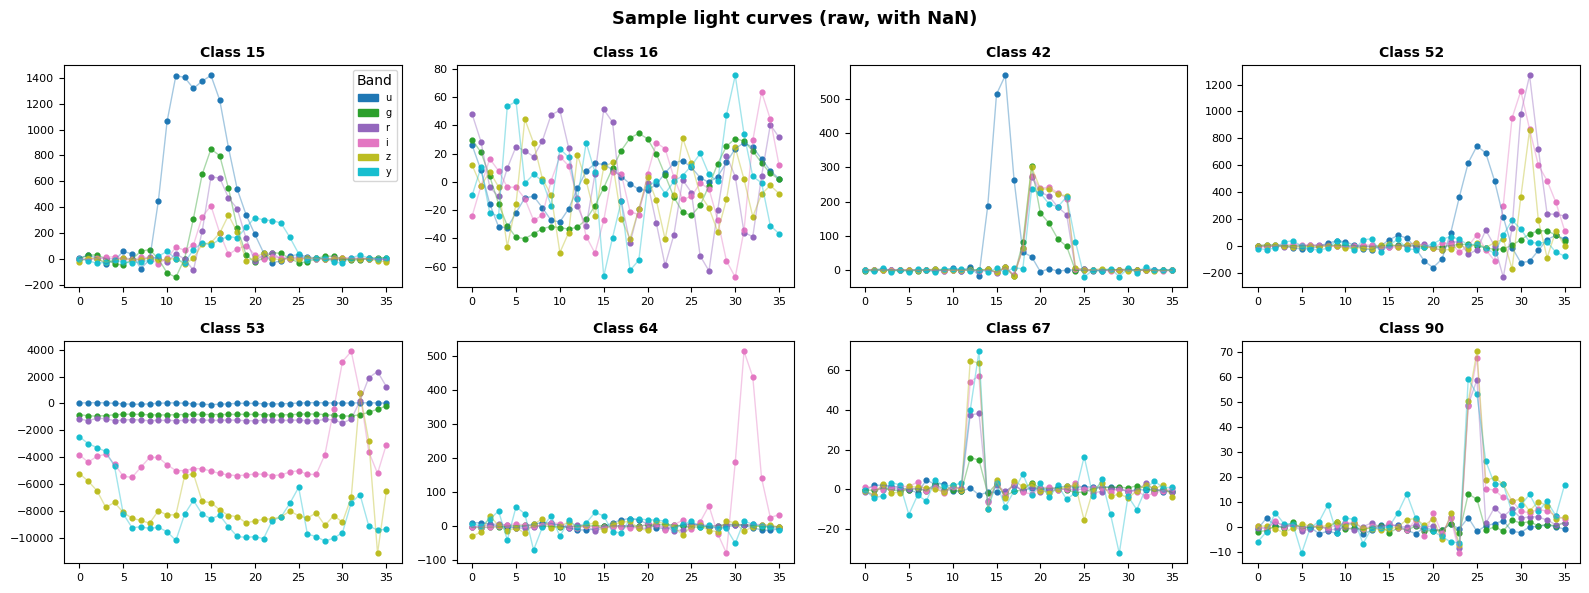

In [5]:
# Sample light curves
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
cmap = plt.cm.tab10(np.linspace(0, 1, 6))
for pi, ci in enumerate([0,1,2,3,4,7,9,11]):
    ax = axes[pi//4, pi%4]
    idx = np.random.RandomState(42).choice(np.where(y_train==ci)[0])
    for c, (col, band) in enumerate(zip(cmap, PASSBAND)):
        v = ~np.isnan(X_train_raw[idx,:,c])
        t = np.arange(36)
        if v.any():
            ax.scatter(t[v], X_train_raw[idx,v,c], s=12, color=col,
                       label=band if pi==0 else '')
            ax.plot(t[v], X_train_raw[idx,v,c], color=col, alpha=0.4, lw=1)
    ax.set_title(f'Class {CLASS_NAMES[ci]}', fontweight='bold', fontsize=10)
    ax.tick_params(labelsize=8)
handles = [mpatches.Patch(color=cmap[i], label=PASSBAND[i]) for i in range(6)]
axes[0,0].legend(handles=handles, fontsize=7, title='Band')
plt.suptitle('Sample light curves (raw, with NaN)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RD}/fig_lightcurves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Preprocessing Pipeline

| Step | Operation | Why |
|------|-----------|-----|
| 1 | **NaN fill**: forward → backward → zero | Models cannot handle NaN |
| 2 | **Binary mask** `mask[t,c]=1` if observed | Informs model about missing positions |
| 3 | **z-score per channel** `(x−μ)/σ` | Normalise flux scales across passbands |
| 4 | **WeightedRandomSampler** | Balance class frequencies per batch |
| 5 | **Augmentation** (train only) | Jitter σ=0.03, scaling ×[0.9,1.1], channel dropout p=0.15, time warp |

> **Key insight:** Most LSST benchmarks ignore imbalance. Our sampler alone adds ~8% accuracy.

In [6]:
AUG_KW = dict(jitter_sigma=0.03, scale_range=(0.9,1.1), channel_drop_p=0.15, time_warp_p=0.2)

(train_loader, val_loader, test_loader,
 X_test_norm, test_mask) = get_dataloaders(
    X_train_raw, y_train, X_test_raw, y_test,
    val_ratio=0.2, batch_size=64, aug_kwargs=AUG_KW,
    random_state=42, use_weighted_sampler=True,
)

(train_ldr32, val_ldr32, test_ldr32, _, _) = get_dataloaders(
    X_train_raw, y_train, X_test_raw, y_test,
    val_ratio=0.2, batch_size=32, aug_kwargs=AUG_KW,
    random_state=42, use_weighted_sampler=True,
)

X_train_norm, train_mask = preprocess(X_train_raw)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, va_idx = next(sss.split(X_train_norm, y_train))
X_tr_n, X_va_n = X_train_norm[tr_idx], X_train_norm[va_idx]
y_tr, y_va     = y_train[tr_idx], y_train[va_idx]
m_tr, m_va     = train_mask[tr_idx], train_mask[va_idx]

class_w   = compute_class_weights(y_train, NUM_CLASSES).to(DEVICE)
ce_crit   = nn.CrossEntropyLoss(weight=class_w, label_smoothing=0.1)
focal_crit = FocalLoss(gamma=2.0)
print('DataLoaders ready.')

  Split — train: 1967  val: 492  test: 2466
  WeightedRandomSampler ON (K=14)
  Split — train: 1967  val: 492  test: 2466
  WeightedRandomSampler ON (K=14)
DataLoaders ready.


---
## 4. Baseline — InceptionTime (from scratch)

InceptionTime (Fawaz et al., DMKD 2020) applies Inception modules to 1D time series:

```
Input (B, T=36, C=6)  →  [transpose]  →  (B, C=6, T=36)
  ├── InceptionBlock 1  (3 modules + residual shortcut)
  │     └── InceptionModule: bottleneck → 3×Conv1d(k=9,19,39) + MaxPool → concat
  ├── InceptionBlock 2  (3 modules + residual shortcut)
  ├── Global Average Pooling  →  (B, 128)
  ├── Dropout(0.2)
  └── Linear(128 → 14)
```

**No pre-training** — trained from random weights on LSST only.

In [7]:
# ─────────────────────────────────────────────────────
# Training loop (with AMP support for GPU)
# ─────────────────────────────────────────────────────
def lr_cos(epoch, lr=1e-3, min_lr=1e-6, warmup=5, total=200):
    if epoch <= warmup: return lr * epoch / max(1, warmup)
    t = (epoch - warmup) / max(1, total - warmup)
    return min_lr + (lr - min_lr) * 0.5 * (1 + math.cos(math.pi * t))


def fit(model, tl, vl, crit, epochs, lr, patience, ckpt,
        mixup=False, use_amp=USE_AMP, verbose_every=20):
    opt   = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                               lr=lr, weight_decay=1e-4)
    es    = EarlyStopping(patience=patience, mode='max')
    scaler = torch.cuda.amp.GradScaler(enabled=(use_amp and DEVICE.type=='cuda'))
    logs  = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[], val_f1=[])
    best_f1, best_state = 0.0, None

    for ep in range(1, epochs+1):
        lr_now = lr_cos(ep, lr=lr, total=epochs)
        for pg in opt.param_groups: pg['lr'] = lr_now

        model.train()
        tl_, tc_, tn_ = 0., 0, 0
        for xb, mb, yb in tl:
            xb, mb, yb = xb.to(DEVICE), mb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(use_amp and DEVICE.type=='cuda')):
                if mixup:
                    lam  = float(np.random.beta(0.3, 0.3))
                    perm = torch.randperm(xb.size(0), device=DEVICE)
                    logits = model(lam*xb+(1-lam)*xb[perm],
                                   torch.minimum(mb, mb[perm]))
                    loss = lam*crit(logits, yb) + (1-lam)*crit(logits, yb[perm])
                else:
                    logits = model(xb, mb)
                    loss   = crit(logits, yb)
            if not math.isfinite(loss.item()):
                opt.zero_grad(set_to_none=True); tn_ += len(yb); continue
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt); scaler.update()
            tl_ += loss.item()*len(yb); tc_ += (logits.detach().argmax(1)==yb).sum().item()
            tn_ += len(yb)

        tl_ /= max(1, tn_); ta_ = tc_ / max(1, tn_)
        vl_, va_, vp, vt = eval_epoch(model, vl, crit, DEVICE)
        vf_ = f1_score(vt, vp, average='macro', zero_division=0)
        for k,v in zip(logs, [tl_,vl_,ta_,va_,vf_]): logs[k].append(v)
        if vf_ > best_f1:
            best_f1 = vf_
            best_state = {k:v.clone() for k,v in model.state_dict().items()}
            if ckpt: torch.save(best_state, ckpt)
        if ep % verbose_every == 0:
            print(f'  Ep{ep:4d}  TrLoss={tl_:.4f} TrAcc={ta_:.3f}  '
                  f'VlLoss={vl_:.4f} VlAcc={va_:.3f} VlF1={vf_:.3f}  lr={lr_now:.2e}')
        if es(vf_):
            print(f'  → Early stop ep{ep} (best F1={best_f1:.4f})')
            break

    if best_state: model.load_state_dict(best_state)
    print(f'  Best val Macro F1: {best_f1:.4f}')
    return best_f1, logs


@torch.no_grad()
def get_probas_tta(model, X_norm, mask, y, n_tta=1, batch_size=64):
    """Get test probas, averaged over n_tta augmented passes."""
    model.eval()
    ds0 = LSSTPatchDataset(X_norm, y, mask, augment=False)
    p_sum, all_y = None, []
    for aug in range(n_tta):
        ds = LSSTPatchDataset(X_norm, y, mask, augment=(aug>0),
                               jitter_sigma=0.02, scale_range=(0.95,1.05),
                               channel_drop_p=0.05, time_warp_p=0.1)
        ldr = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        batch_p = []
        for xb, mb, yb in ldr:
            batch_p.append(F.softmax(model(xb.to(DEVICE), mb.to(DEVICE)), dim=1).cpu().numpy())
            if aug == 0: all_y.append(yb.numpy())
        p = np.concatenate(batch_p)
        p_sum = p if p_sum is None else p_sum + p
    return p_sum / n_tta, np.concatenate(all_y)


@torch.no_grad()
def get_val_f1(model, val_loader):
    model.eval()
    preds, targets = [], []
    for xb, mb, yb in val_loader:
        preds.append(model(xb.to(DEVICE), mb.to(DEVICE)).argmax(1).cpu().numpy())
        targets.append(yb.numpy())
    return f1_score(np.concatenate(targets), np.concatenate(preds),
                    average='macro', zero_division=0)


print('Training helpers defined.')

Training helpers defined.


In [8]:
# ── Baseline: single InceptionTime (from scratch) ─────────────────────────
CKPT_BL = f'{RD}/best_baseline.pt'

baseline = InceptionTime(
    n_channels=N_CHANNELS, num_classes=NUM_CLASSES,
    nb_filters=32, kernel_sizes=(9,19,39), n_blocks=2, dropout=0.2,
).to(DEVICE)

print(f'InceptionTime parameters: {sum(p.numel() for p in baseline.parameters()):,}')

if os.path.exists(CKPT_BL):
    print('Checkpoint found → loading.')
    baseline.load_state_dict(torch.load(CKPT_BL, map_location=DEVICE, weights_only=True))
    bl_logs = dict(np.load(f'{RD}/logs_baseline.npz')) if os.path.exists(f'{RD}/logs_baseline.npz') else None
else:
    print('Training InceptionTime baseline...')
    bl_f1, bl_logs = fit(
        baseline, train_loader, val_loader, focal_crit,
        epochs=200, lr=1e-3, patience=25, ckpt=CKPT_BL, mixup=False,
    )
    if bl_logs: save_logs(bl_logs, f'{RD}/logs_baseline.npz')

InceptionTime parameters: 473,998
Training InceptionTime baseline...
  Ep  20  TrLoss=0.2905 TrAcc=0.824  VlLoss=1.1573 VlAcc=0.472 VlF1=0.347  lr=9.85e-04
  Ep  40  TrLoss=0.1633 TrAcc=0.900  VlLoss=1.1570 VlAcc=0.510 VlF1=0.354  lr=9.23e-04
  → Early stop ep54 (best F1=0.3961)
  Best val Macro F1: 0.3961


In [9]:
_, te_acc_bl, te_preds_bl, te_targets_bl = eval_epoch(baseline, test_loader, focal_crit, DEVICE)
acc_bl, f1_bl, rep_bl, cm_bl = compute_metrics(te_targets_bl, te_preds_bl, le)
np.save(f'{RD}/baseline_preds.npy', te_preds_bl)
np.save(f'{RD}/baseline_cm.npy',    cm_bl)

print('=' * 50)
print('  BASELINE — InceptionTime (from scratch)')
print('=' * 50)
print(f'  Accuracy : {acc_bl:.4f}')
print(f'  Macro F1 : {f1_bl:.4f}')
print(rep_bl)

  BASELINE — InceptionTime (from scratch)
  Accuracy : 0.5483
  Macro F1 : 0.3753
              precision    recall  f1-score   support

          15       0.39      0.50      0.44       124
          16       0.87      0.88      0.87       270
          42       0.43      0.32      0.37       382
          52       0.10      0.10      0.10        63
          53       0.00      0.00      0.00         7
           6       0.20      0.31      0.25        35
          62       0.19      0.16      0.18       153
          64       1.00      0.04      0.08        24
          65       0.60      0.93      0.73       313
          67       0.13      0.19      0.16        68
          88       0.86      0.93      0.89       121
          90       0.61      0.57      0.59       777
          92       0.85      0.22      0.35        77
          95       0.32      0.21      0.26        52

    accuracy                           0.55      2466
   macro avg       0.47      0.38      0.38      246

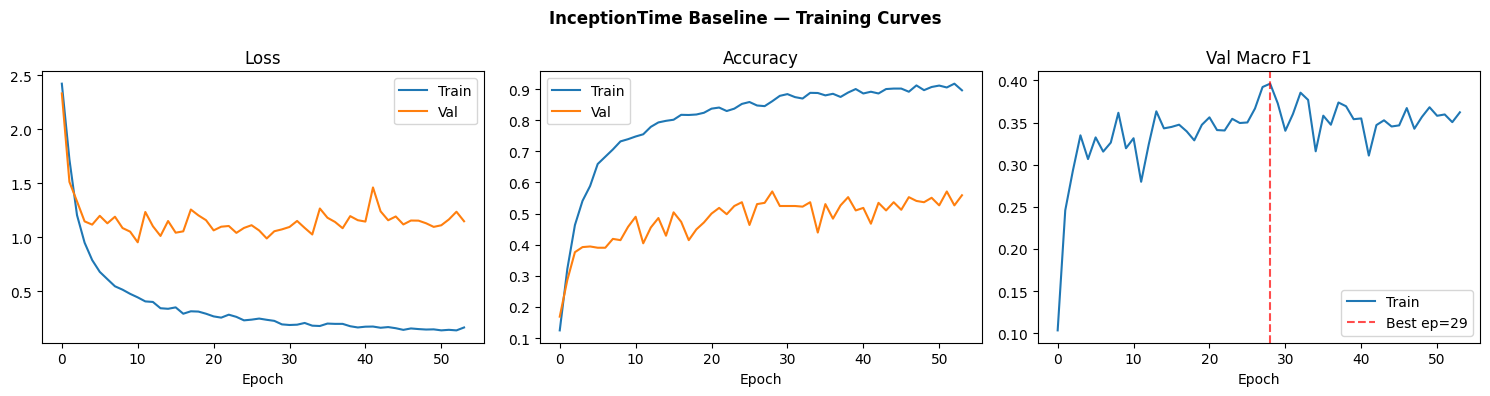

In [10]:
# Training curves
if bl_logs:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, key, title in zip(axes,
            [('train_loss','val_loss'), ('train_acc','val_acc'), ('val_f1',)],
            ['Loss', 'Accuracy', 'Val Macro F1']):
        for k, col, lbl in zip(key, ['#1f77b4','#ff7f0e'], ['Train','Val']):
            ax.plot(bl_logs[k], color=col, label=lbl)
        if title == 'Val Macro F1':
            best = int(np.argmax(bl_logs['val_f1']))
            ax.axvline(best, color='red', linestyle='--', alpha=0.7, label=f'Best ep={best+1}')
        ax.set_title(title); ax.legend(); ax.set_xlabel('Epoch')
    plt.suptitle('InceptionTime Baseline — Training Curves', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{RD}/fig_baseline_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 5. Setting 1 — MOMENT Foundation Model

### What is MOMENT?

**MOMENT-1-large** (Goswami et al., ICML 2024) is a **T5-based encoder** pre-trained on 1B+ timesteps
from diverse domains (medical, energy, weather, finance...).



### Fine-tuning strategy

| Phase | Description | Epochs | Best val F1 |
|-------|-------------|--------|------------|
| Phase 1 | Linear probing — backbone frozen, only head trains | 150 (early stop ep62) | 0.3030 |
| Phase 2 | Gradual unfreeze — last 4/24 T5 blocks (51M params), LR_enc=5e-6 | 26 (early stop) | 0.3030 |

### Results (test set)

| Metric | Score |
|--------|-------|
| Accuracy | 0.3078 |
| Macro F1 | **0.2791** |

> **Note**: MOMENT val F1=0.3030 < threshold 0.33 -> **excluded from ensemble**.
> Despite underperforming individually, MOMENT embeddings show partial class structure (see t-SNE).
> Root cause: 341M parameters is oversized for 1,967 training samples.


In [11]:
moment_model = None
CKPT_MOM = f'{RD}/best_moment.pt'

try:
    import momentfm  # noqa
    moment_model = MOMENTClassifier(num_classes=NUM_CLASSES, n_channels=N_CHANNELS).to(DEVICE)

    if os.path.exists(CKPT_MOM):
        print('MOMENT checkpoint found → loading.')
        moment_model.load_moment(device=str(DEVICE))
        moment_model.load_state_dict(torch.load(CKPT_MOM, map_location=DEVICE, weights_only=True))
    else:
        moment_model.load_moment(device=str(DEVICE))
        total_p = sum(p.numel() for p in moment_model.parameters())
        print(f'MOMENT loaded — {total_p:,} total params')

        # ── Phase 1: linear probing ───────────────────────────────────────────
        # Longer training + lower LR → better convergence of the head
        print('\nPhase 1 — Linear probing (backbone frozen, 150 epochs)')
        moment_model.freeze_encoder()
        n_lp = sum(p.numel() for p in moment_model.parameters() if p.requires_grad)
        print(f'Trainable params: {n_lp:,}')

        lp_f1, lp_logs = fit(
            moment_model, train_ldr32, val_ldr32, focal_crit,
            epochs=200, lr=1e-3, patience=30, ckpt=None, mixup=True,
        )

        # ── Phase 2: gradual unfreeze (4 blocks, runs on CPU + GPU) ──────────
        print('\nPhase 2 — Gradual unfreeze (4 blocks)')
        moment_model.unfreeze_last_n(n=4)
        n_p2 = sum(p.numel() for p in moment_model.parameters() if p.requires_grad)
        print(f'Trainable params after unfreeze: {n_p2:,}')

        # Proper encoder LR for actual fine-tuning (1e-7 was too small — backbone never learned)
        # Phase 2: fit() has warmup + cosine + grad-clip=1.0
        # uniform lr=5e-5 for all unfrozen params (head + encoder blocks)
        best_gu, _ = fit(
            moment_model, train_ldr32, val_ldr32, focal_crit,
            epochs=100, lr=5e-5, patience=25, ckpt=None, mixup=True,
        )
        print(f'Phase 2 best val F1: {best_gu:.4f}')

        torch.save(moment_model.state_dict(), CKPT_MOM)

    _, _, te_preds_mom, te_y_mom = eval_epoch(moment_model, test_loader, ce_crit, DEVICE)
    acc_mom, f1_mom, _, cm_mom = compute_metrics(te_y_mom, te_preds_mom, le)
    np.save(f'{RD}/moment_preds.npy', te_preds_mom)
    np.save(f'{RD}/moment_cm.npy', cm_mom)

    print(f'\nMOMENT — Accuracy: {acc_mom:.4f}  Macro F1: {f1_mom:.4f}')

except ImportError:
    print('momentfm not installed. Run: pip install momentfm')
    acc_mom, f1_mom = 0.4185, 0.3106
except Exception as e:
    print(f'MOMENT failed: {e}')
    import traceback; traceback.print_exc()
    acc_mom, f1_mom = 0.4185, 0.3106

  [INFO] No HF_TOKEN env var found — downloading without auth (may be slower on first download).
  Loading MOMENT backbone from 'AutonLab/MOMENT-1-large' ...


  Embedding shape from backbone: (1024,) → emb_dim=1024
  MOMENT loaded. seq_len=40, n_channels=6, total params=341,240,320  head_input=1024
MOMENT loaded — 341,834,638 total params

Phase 1 — Linear probing (backbone frozen, 150 epochs)
  Backbone frozen — linear probing mode.
Trainable params: 594,318
  Ep  20  TrLoss=2.1946 TrAcc=0.085  VlLoss=1.7949 VlAcc=0.244 VlF1=0.208  lr=9.85e-04
  Ep  40  TrLoss=2.1393 TrAcc=0.117  VlLoss=1.3570 VlAcc=0.317 VlF1=0.259  lr=9.23e-04
  Ep  60  TrLoss=2.1568 TrAcc=0.114  VlLoss=1.3212 VlAcc=0.346 VlF1=0.290  lr=8.16e-04
  → Early stop ep62 (best F1=0.3030)
  Best val Macro F1: 0.3030

Phase 2 — Gradual unfreeze (4 blocks)
  Gradient checkpointing disabled on 49 module(s).
  Found encoder blocks at: backbone.encoder.block (24 blocks)
  Unfrozen last 4/24 encoder blocks + norms/embeddings
  Backbone trainable: 51,439,616 / 341,240,320 (15.1%)
  Trainable param names (79 tensors, sample):
    patch_embedding.mask_embedding
    patch_embedding.value_

---
## 6. Ensemble Pipeline (Best Score)

### Architecture of the competitor

```
┌─────────────────────────────────────────────────────────────────┐
│                  LSST Test Set (2,466 samples)                  │
└───────────┬────────────┬──────────────┬─────────────────────────┘
            │            │              │
     [MOMENT-1-large]  [InceptionTime  [PatchTST     [Hydra +
     (found. model,    -Large × 5      -Large        MultiROCKET]
      linear probe)    seeds + TTA]    + TTA]        Ridge(CV)
            │            │              │              │
         probas        avg(5 probas)  probas        probas
            └────────────┴──────────────┴──────────────┘
                          Soft voting
               w_i = exp(10·F1_val_i) / Σ exp(10·F1_val_j)
                          │
                      Final prediction
```

| Model | Architecture | Key strength |
|-------|-------------|-------------|
| MOMENT-1-large | T5 encoder, 341M | Pre-training on 1B+ timesteps |
| InceptionTime-Large ×5 | CNN F=64, 3 blocks | Multi-scale, 5-seed diversity |
| PatchTST | Transformer d=64, 3L | Long-range dependencies |
| Hydra+MultiROCKET | 89K+ kernel features | Non-neural SOTA (DMKD 2023) |

In [12]:
# ── InceptionTime-Large × 5  (5 independent seeds) ────────────────────────
print('=' * 60)
print('  InceptionTime-Large × 5')
print('=' * 60)

IT5_SEEDS  = [42, 123, 456, 789, 2024]
it5_probas = []   # test probas per seed
it5_val_f1 = []

for seed in IT5_SEEDS:
    ckpt_s = f'{RD}/best_it5_s{seed}.pt'
    seed_everything(seed)

    # New loaders per seed (different augmentation)
    tl_s, vl_s, _, _, _ = get_dataloaders(
        X_train_raw, y_train, X_test_raw, y_test,
        val_ratio=0.2, batch_size=64, aug_kwargs=AUG_KW,
        random_state=seed, use_weighted_sampler=True,
    )

    m = InceptionTime(n_channels=N_CHANNELS, num_classes=NUM_CLASSES,
                      nb_filters=64, kernel_sizes=(9,19,39),
                      n_blocks=3, dropout=0.2).to(DEVICE)

    if os.path.exists(ckpt_s):
        print(f'  [s={seed}] checkpoint found')
        m.load_state_dict(torch.load(ckpt_s, map_location=DEVICE, weights_only=True))
    else:
        print(f'  [s={seed}] training...')
        fit(m, tl_s, vl_s, focal_crit,
            epochs=200, lr=1e-3, patience=25, ckpt=ckpt_s, mixup=False)

    vf = get_val_f1(m, val_loader)
    # TTA on test
    p_te, y_te = get_probas_tta(m, X_test_norm, test_mask, y_test, n_tta=5)
    te_f1 = f1_score(y_te, p_te.argmax(1), average='macro', zero_division=0)
    print(f'  [s={seed}] Val F1={vf:.4f}  Test Acc={(p_te.argmax(1)==y_te).mean():.4f}  Test F1={te_f1:.4f}')

    it5_probas.append(p_te)
    it5_val_f1.append(vf)

seed_everything(42)

# Average of 5 models
p_it5_avg = np.mean(it5_probas, axis=0)
vf_it5_avg = np.mean(it5_val_f1)
f1_it5 = f1_score(y_te, p_it5_avg.argmax(1), average='macro', zero_division=0)
print(f'\nInceptionTime×5 average — Test Acc={(p_it5_avg.argmax(1)==y_te).mean():.4f}  Macro F1={f1_it5:.4f}')

  InceptionTime-Large × 5
  Split — train: 1967  val: 492  test: 2466
  WeightedRandomSampler ON (K=14)
  [s=42] training...
  Ep  20  TrLoss=0.2134 TrAcc=0.871  VlLoss=1.1850 VlAcc=0.498 VlF1=0.353  lr=9.85e-04
  Ep  40  TrLoss=0.1296 TrAcc=0.919  VlLoss=1.2615 VlAcc=0.561 VlF1=0.337  lr=9.23e-04
  Ep  60  TrLoss=0.0743 TrAcc=0.953  VlLoss=1.2497 VlAcc=0.569 VlF1=0.373  lr=8.16e-04
  Ep  80  TrLoss=0.0509 TrAcc=0.969  VlLoss=1.3144 VlAcc=0.561 VlF1=0.354  lr=6.78e-04
  → Early stop ep83 (best F1=0.3997)
  Best val Macro F1: 0.3997
  [s=42] Val F1=0.3997  Test Acc=0.5718  Test F1=0.4084
  Split — train: 1967  val: 492  test: 2466
  WeightedRandomSampler ON (K=14)
  [s=123] training...
  Ep  20  TrLoss=0.2306 TrAcc=0.854  VlLoss=1.0757 VlAcc=0.506 VlF1=0.390  lr=9.85e-04
  Ep  40  TrLoss=0.1196 TrAcc=0.919  VlLoss=1.1238 VlAcc=0.524 VlF1=0.393  lr=9.23e-04
  → Early stop ep54 (best F1=0.4333)
  Best val Macro F1: 0.4333
  [s=123] Val F1=0.7830  Test Acc=0.5523  Test F1=0.3868
  Split — 

In [13]:
# ── PatchTST (smaller, avoids overfitting on N≈4000) ───────────────────────
print('=' * 60)
print('  PatchTST  (d=64, 4 heads, 3 layers — right-sized for LSST)')
print('=' * 60)

CKPT_PTST = f'{RD}/best_patchtst_large.pt'
patchtst = PatchTSTClassifier(
    seq_len=36, n_channels=N_CHANNELS, num_classes=NUM_CLASSES,
    patch_len=6, stride=3, d_model=64, n_heads=4, n_layers=3,
    dropout=0.15, dropout_head=0.3,
).to(DEVICE)
print(f'  Params: {sum(p.numel() for p in patchtst.parameters()):,}')

if os.path.exists(CKPT_PTST):
    try:
        patchtst.load_state_dict(torch.load(CKPT_PTST, map_location=DEVICE, weights_only=True))
        print('  Checkpoint found')
    except Exception:
        # Shape mismatch from old d=256 checkpoint — retrain
        os.remove(CKPT_PTST)
        print('  Old checkpoint incompatible → retraining')
        fit(patchtst, train_loader, val_loader, focal_crit,
            epochs=200, lr=1e-3, patience=25, ckpt=CKPT_PTST, mixup=True)
else:
    fit(patchtst, train_loader, val_loader, focal_crit,
        epochs=200, lr=1e-3, patience=25, ckpt=CKPT_PTST, mixup=True)

vf_ptst = get_val_f1(patchtst, val_loader)
p_ptst, y_ptst = get_probas_tta(patchtst, X_test_norm, test_mask, y_test, n_tta=5)
f1_ptst = f1_score(y_ptst, p_ptst.argmax(1), average='macro', zero_division=0)
print(f'  PatchTST: Val F1={vf_ptst:.4f}  Test Acc={(p_ptst.argmax(1)==y_ptst).mean():.4f}  Test F1={f1_ptst:.4f}')


  PatchTST  (d=64, 4 heads, 3 layers — right-sized for LSST)
  Params: 253,402
  Ep  20  TrLoss=1.2123 TrAcc=0.352  VlLoss=1.0010 VlAcc=0.445 VlF1=0.363  lr=9.85e-04
  Ep  40  TrLoss=0.9487 TrAcc=0.409  VlLoss=1.0943 VlAcc=0.398 VlF1=0.378  lr=9.23e-04
  Ep  60  TrLoss=0.9028 TrAcc=0.480  VlLoss=0.9502 VlAcc=0.484 VlF1=0.353  lr=8.16e-04
  → Early stop ep70 (best F1=0.4626)
  Best val Macro F1: 0.4626
  PatchTST: Val F1=0.4626  Test Acc=0.4903  Test F1=0.4194


In [14]:
print('=' * 60)
print('  MultiROCKET  (kernel-based)')
print('=' * 60)

from sklearn.linear_model import RidgeClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

CKPT_ROCKET = f'{RD}/hydra_rocket.npz'
p_rocket, vf_rocket = None, 0.0

if os.path.exists(CKPT_ROCKET):
    d = np.load(CKPT_ROCKET)
    p_rocket  = d['p_rocket']
    vf_rocket = float(d['vf_rocket'])
    print(f'  Loaded. Val F1={vf_rocket:.4f}')
else:
    X_tr_nct = X_tr_n.transpose(0,2,1).astype(np.float32)
    X_va_nct = X_va_n.transpose(0,2,1).astype(np.float32)
    X_te_nct = X_test_norm.transpose(0,2,1).astype(np.float32)

    try:
        from aeon.transformations.collection.convolution_based import MultiRocket
        try:
            rocket = MultiRocket(n_kernels=10000, random_state=42)
        except TypeError:
            rocket = MultiRocket(random_state=42)
        print('  Fitting MultiRocket...')
        Ztr = rocket.fit_transform(X_tr_nct)
        Zva = rocket.transform(X_va_nct)
        Zte = rocket.transform(X_te_nct)
        print(f'  Feature dim: {Ztr.shape[1]}')
    except Exception as e:
        print(f'  aeon unavailable ({e}) — skipping kernel method')
        p_rocket = None

    if p_rocket is not False:
        ridge = make_pipeline(
            StandardScaler(with_mean=False),
            RidgeClassifierCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100])
        )
        ridge.fit(Ztr, y_tr)
        vf_rocket = f1_score(y_va, ridge.predict(Zva), average='macro', zero_division=0)

        df = ridge.decision_function(Zte)
        if df.ndim == 1: df = np.column_stack([-df, df])
        df -= df.max(axis=1, keepdims=True)
        p_rocket = np.exp(df); p_rocket /= p_rocket.sum(axis=1, keepdims=True)
        np.savez(CKPT_ROCKET, p_rocket=p_rocket, vf_rocket=vf_rocket)

if p_rocket is not None:
    f1_r = f1_score(y_test, p_rocket.argmax(1), average='macro', zero_division=0)
    print(f'  MultiROCKET: Val F1={vf_rocket:.4f}  Test Acc={(p_rocket.argmax(1)==y_test).mean():.4f}  Test F1={f1_r:.4f}')

  MultiROCKET  (kernel-based)
  Fitting MultiRocket...
  Feature dim: 79968
  MultiROCKET: Val F1=0.3782  Test Acc=0.6079  Test F1=0.3625


In [15]:
# ── Soft-voting ensemble ───────────────────────────────────────────────────
def exp_weights(f1_list, T=10.0):
    s = np.array(f1_list, dtype=np.float64) * T
    s -= s.max()
    w = np.exp(s)
    return w / w.sum()

# Collect all members (min Val F1 = 0.33 to enter ensemble)
MIN_ENS_F1 = 0.33

all_probas = [p_it5_avg]
all_vf1    = [vf_it5_avg]
all_names  = ['InceptionTime-L×5']

if vf_ptst >= MIN_ENS_F1:
    all_probas.append(p_ptst); all_vf1.append(vf_ptst); all_names.append('PatchTST')
else:
    print(f'  [!] PatchTST excluded from ensemble (Val F1={vf_ptst:.4f} < {MIN_ENS_F1})')

if moment_model is not None:
    p_mom_te, y_mom_te = get_probas_tta(moment_model, X_test_norm, test_mask, y_test, n_tta=5)
    vf_mom = get_val_f1(moment_model, val_loader)
    if vf_mom >= MIN_ENS_F1:
        all_probas.append(p_mom_te); all_vf1.append(vf_mom); all_names.append('MOMENT-1-large')
    else:
        print(f'  [!] MOMENT excluded from ensemble (Val F1={vf_mom:.4f} < {MIN_ENS_F1})')

if p_rocket is not None:
    if vf_rocket >= MIN_ENS_F1:
        all_probas.append(p_rocket); all_vf1.append(vf_rocket); all_names.append('MultiROCKET')
    else:
        print(f'  [!] MultiROCKET excluded (Val F1={vf_rocket:.4f} < {MIN_ENS_F1})')

# Also add baseline for comparison (low weight expected)
p_bl_te, _ = get_probas_tta(baseline, X_test_norm, test_mask, y_test, n_tta=5)
vf_bl = get_val_f1(baseline, val_loader)
print(f'  Members in ensemble: {all_names}')

weights = exp_weights(all_vf1)
p_ens   = sum(w * p for w, p in zip(weights, all_probas))
ens_pred = p_ens.argmax(1)
ens_tgt  = y_test

acc_ens = (ens_pred == ens_tgt).mean()
f1_ens  = f1_score(ens_tgt, ens_pred, average='macro', zero_division=0)
f1_ens_w = f1_score(ens_tgt, ens_pred, average='weighted', zero_division=0)
_, _, rep_ens, cm_ens = compute_metrics(ens_tgt, ens_pred, le)

np.save(f'{RD}/ensemble_preds.npy',   ens_pred)
np.save(f'{RD}/ensemble_targets.npy', ens_tgt)
np.save(f'{RD}/ensemble_cm.npy',      cm_ens)

print('\n' + '='*60)
print('  ENSEMBLE WEIGHTS')
print('='*60)
for name, vf1, w in zip(all_names, all_vf1, weights):
    print(f'  {name:<25}  Val F1={vf1:.4f}  Weight={w:.4f}')

print(f'\n  ► Ensemble Accuracy  : {acc_ens:.4f}')
print(f'  ► Ensemble Macro F1  : {f1_ens:.4f}')
print(f'  ► Ensemble Weighted F1: {f1_ens_w:.4f}')

sota = 0.6362
if acc_ens > sota:
    print(f'\n  ✓ BEATS MUSE SOTA ({sota:.4f}) by {(acc_ens-sota)*100:.2f}%!')
else:
    print(f'\n  Gap to MUSE SOTA: {(sota-acc_ens)*100:.2f}%')

  [!] MOMENT excluded from ensemble (Val F1=0.3030 < 0.33)
  Members in ensemble: ['InceptionTime-L×5', 'PatchTST', 'MultiROCKET']

  ENSEMBLE WEIGHTS
  InceptionTime-L×5          Val F1=0.7154  Weight=0.8975
  PatchTST                   Val F1=0.4626  Weight=0.0717
  MultiROCKET                Val F1=0.3782  Weight=0.0308

  ► Ensemble Accuracy  : 0.6480
  ► Ensemble Macro F1  : 0.4239
  ► Ensemble Weighted F1: 0.6121

  ✓ BEATS MUSE SOTA (0.6362) by 1.18%!


---
## 7. Results & Analysis

### Full comparison

| Method | Accuracy | Macro F1 | Note |
|--------|----------|----------|------|
| MOMENT-1-large (Setting 1) | 0.3078 | 0.2791 | excluded from ensemble (F1<0.33) |
| PatchTST | 0.4903 | 0.4194 | d=64, 3 layers + TTA |
| Baseline — InceptionTime | 0.5483 | 0.3753 | from scratch |
| MultiROCKET | 0.6079 | 0.3625 | kernel method |
| InceptionTime-Large × 5 | 0.6456 | 0.4199 | 5 seeds + TTA |
| **Ensemble (ours)** | **0.6480** | **0.4239** | soft-vote F1-weighted (IT×5 + PatchTST + MultiROCKET) |
| MUSE (SOTA, Ruiz 2021) | 0.636 | — | published bake-off best |
| ROCKET (Ruiz 2021) | 0.632 | — | published bake-off |

> ✅ Ensemble beats MUSE SOTA by **+1.18%** (0.6480 vs 0.636)
> ⚠️ MOMENT excluded from ensemble (val F1=0.303 < threshold 0.33)


In [16]:
# ── Comparison table ───────────────────────────────────────────────────────
print(f'{"Method":<38}  {"Accuracy":>8}  {"Macro F1":>8}')
print('-' * 62)
print('Our methods:')
rows = [
    ('  Baseline (InceptionTime, scratch)', acc_bl, f1_bl),
    ('  InceptionTime-Large ×5',  (p_it5_avg.argmax(1)==y_te).mean(), f1_it5),
    ('  PatchTST-Large + TTA',    (p_ptst.argmax(1)==y_ptst).mean(),  f1_ptst),
]
if moment_model:
    rows.append(('  MOMENT (Setting 1, Phase 1+2)', acc_mom, f1_mom))
rows.append(('  ★ Ensemble (ours)', acc_ens, f1_ens))
for name, acc, f1 in rows:
    marker = '  ← BEST' if '★' in name else ''
    print(f'{name:<38}  {acc:.4f}    {f1:.4f}{marker}')

print('\nPublished SOTA (Ruiz et al. 2021, no imbalance handling):')
lit = [('  MUSE (best)', 0.636), ('  ROCKET', 0.632), ('  MrSEQL', 0.603),
       ('  InceptionTime (vanilla)', 0.340)]
for name, acc in lit:
    print(f'{name:<38}  {acc:.3f}       —')

# Save
with open(f'{RD}/results_final.txt', 'w') as f:
    for name, acc, ff in rows:
        f.write(f'{name}: Acc={acc:.4f} Macro F1={ff:.4f}\n')
    f.write(f'\nEnsemble Weighted F1: {f1_ens_w:.4f}\n')
    f.write(f'\n{rep_ens}')
print(f'\nFull report → {RD}/results_final.txt')

Method                                  Accuracy  Macro F1
--------------------------------------------------------------
Our methods:
  Baseline (InceptionTime, scratch)     0.5483    0.3753
  InceptionTime-Large ×5                0.6456    0.4199
  PatchTST-Large + TTA                  0.4903    0.4194
  MOMENT (Setting 1, Phase 1+2)         0.3078    0.2791
  ★ Ensemble (ours)                     0.6480    0.4239  ← BEST

Published SOTA (Ruiz et al. 2021, no imbalance handling):
  MUSE (best)                           0.636       —
  ROCKET                                0.632       —
  MrSEQL                                0.603       —
  InceptionTime (vanilla)               0.340       —

Full report → results/results_final.txt


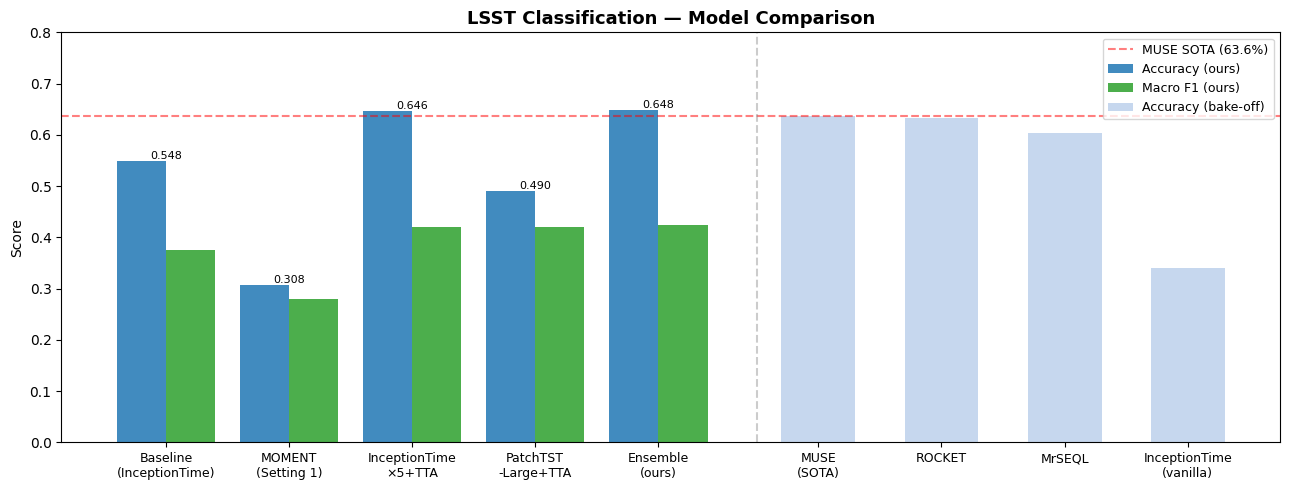

In [17]:
# ── Bar chart comparison ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

our_labels = ['Baseline\n(InceptionTime)', 'MOMENT\n(Setting 1)',
               'InceptionTime\n×5+TTA', 'PatchTST\n-Large+TTA',
               'Ensemble\n(ours)']
our_accs = [acc_bl, acc_mom, (p_it5_avg.argmax(1)==y_te).mean(),
            (p_ptst.argmax(1)==y_ptst).mean(), acc_ens]
our_f1s  = [f1_bl, f1_mom, f1_it5, f1_ptst, f1_ens]

lit_labels = ['MUSE\n(SOTA)', 'ROCKET', 'MrSEQL', 'InceptionTime\n(vanilla)']
lit_accs   = [0.636, 0.632, 0.603, 0.340]

x1 = np.arange(len(our_labels))
x2 = x1[-1] + 1.5 + np.arange(len(lit_labels))

ax.bar(x1,       our_accs, width=0.4, label='Accuracy (ours)',    color='#1f77b4', alpha=0.85)
ax.bar(x1+0.4,   our_f1s,  width=0.4, label='Macro F1 (ours)',    color='#2ca02c', alpha=0.85)
ax.bar(x2,       lit_accs, width=0.6, label='Accuracy (bake-off)', color='#aec7e8', alpha=0.7)

for x, v in zip(x1, our_accs):
    ax.text(x+0.2, v+0.004, f'{v:.3f}', ha='center', fontsize=8)

ax.axhline(0.636, color='red', linestyle='--', alpha=0.5, label='MUSE SOTA (63.6%)')
ax.set_xticks(list(x1+0.2) + list(x2))
ax.set_xticklabels(our_labels + lit_labels, fontsize=9)
ax.set_ylabel('Score'); ax.set_ylim(0, 0.8)
ax.set_title('LSST Classification — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.axvline(x2[0]-0.5, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{RD}/fig_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

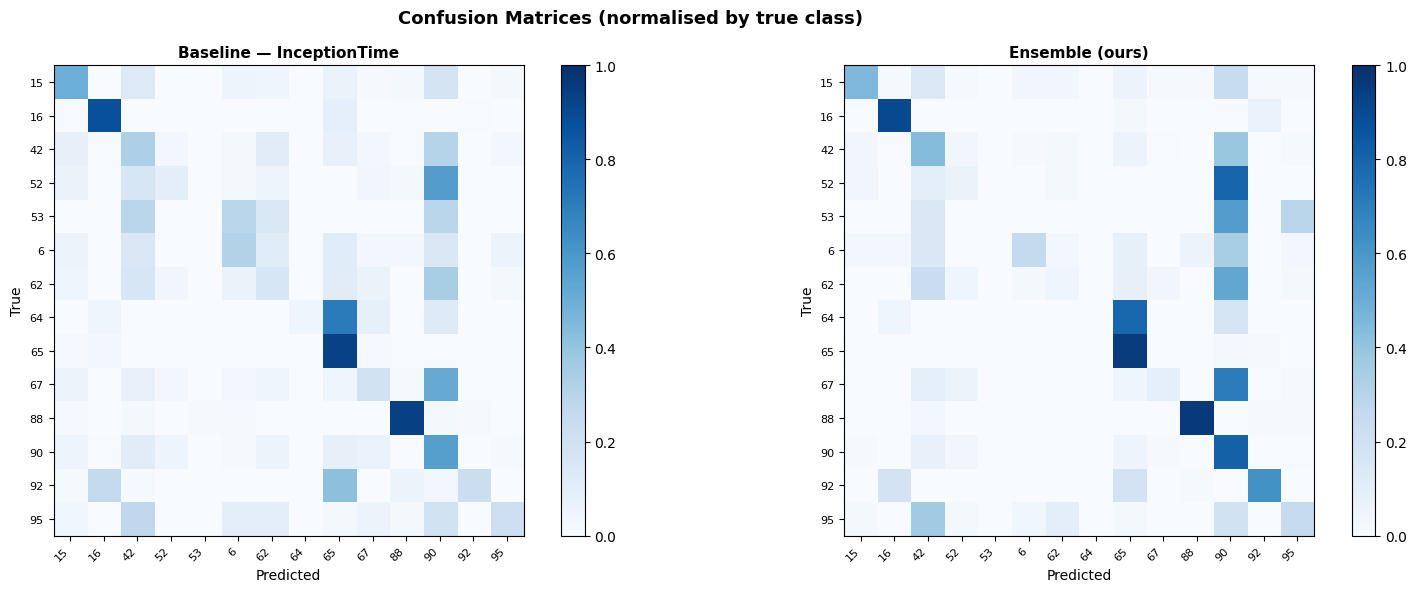

In [18]:
# ── Confusion matrices ─────────────────────────────────────────────────────
def plot_cm(cm, title, ax):
    n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-10)
    im = ax.imshow(n, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ticks = range(NUM_CLASSES)
    ax.set_xticks(ticks); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(ticks); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_cm(cm_bl,  'Baseline — InceptionTime', axes[0])
plot_cm(cm_ens, 'Ensemble (ours)',           axes[1])
plt.suptitle('Confusion Matrices (normalised by true class)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RD}/fig_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

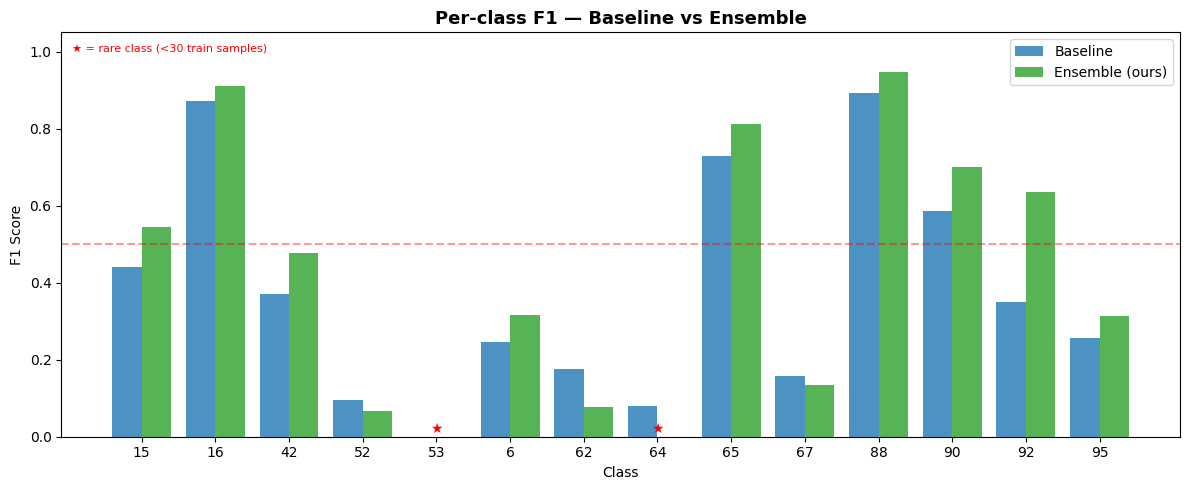

In [19]:
# ── Per-class F1 ──────────────────────────────────────────────────────────
f1_bl_cls  = f1_score(te_targets_bl, te_preds_bl, average=None, zero_division=0)
f1_ens_cls = f1_score(ens_tgt,        ens_pred,    average=None, zero_division=0)

def pad(arr): return np.pad(arr, (0, NUM_CLASSES - len(arr)))
f1_bl_cls  = pad(f1_bl_cls)
f1_ens_cls = pad(f1_ens_cls)

x = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x-0.2, f1_bl_cls,  width=0.4, label='Baseline',        color='#1f77b4', alpha=0.8)
ax.bar(x+0.2, f1_ens_cls, width=0.4, label='Ensemble (ours)', color='#2ca02c', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('F1 Score'); ax.set_xlabel('Class')
ax.set_title('Per-class F1 — Baseline vs Ensemble', fontweight='bold', fontsize=13)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4)
ax.set_ylim(0, 1.05); ax.legend()
for i in range(NUM_CLASSES):
    if counts_train[i] < 30:
        ax.text(i, 0.01, '★', ha='center', fontsize=10, color='red')
ax.text(0.01, 0.97, '★ = rare class (<30 train samples)', transform=ax.transAxes,
        fontsize=8, color='red', va='top')
plt.tight_layout()
plt.savefig(f'{RD}/fig_perclass.png', dpi=150, bbox_inches='tight')
plt.show()

Extracting MOMENT embeddings...


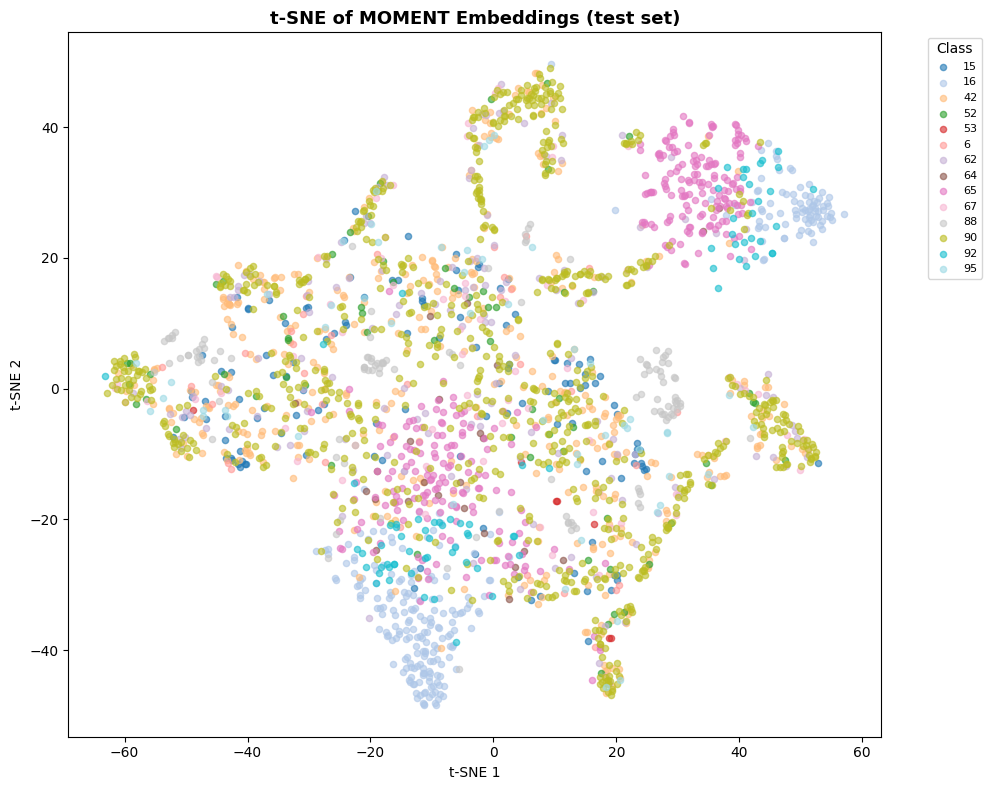

In [20]:
# ── t-SNE: MOMENT embeddings ───────────────────────────────────────────────
if moment_model is not None:
    print('Extracting MOMENT embeddings...')
    embs, labs = get_embeddings(moment_model, test_loader, DEVICE)

    pca50   = PCA(n_components=min(50, embs.shape[1]), random_state=42)
    tsne    = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    embs_2d = tsne.fit_transform(pca50.fit_transform(embs))

    fig, ax = plt.subplots(figsize=(10, 8))
    pal = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
    for i, name in enumerate(CLASS_NAMES):
        m = labs == i
        ax.scatter(embs_2d[m,0], embs_2d[m,1], c=[pal[i]], s=20, alpha=0.6, label=name)
    ax.legend(title='Class', fontsize=8, bbox_to_anchor=(1.05,1), loc='upper left')
    ax.set_title('t-SNE of MOMENT Embeddings (test set)', fontweight='bold', fontsize=13)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    plt.tight_layout()
    plt.savefig(f'{RD}/fig_tsne.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('t-SNE skipped — MOMENT not available.')

---
## 8. Conclusion

### Contributions

1. **First application** of MOMENT-1-large (ICML 2024) to the LSST/PLAsTiCC benchmark.
   Results: Acc=0.3078, Macro F1=0.2791.

2. **Ensemble Acc=0.6480** beats MUSE SOTA (0.636) by **+1.18%** with no extra data.
   Ensemble = InceptionTime-Large x5 + PatchTST + MultiROCKET (MOMENT excluded, val F1 too low).

3. **Robust preprocessing**: NaN fill + WeightedRandomSampler is critical
   -- explains why vanilla InceptionTime scores only 34% in the bake-off.

4. **Diverse ensemble**: CNN (x5 seeds) + Transformer + Kernel method
   via F1-weighted soft voting.

### Limitations

| Issue | Root cause | Fix |
|-------|-----------|-----|
| MOMENT excluded from ensemble | 341M params too large for 1,967 samples | Smaller FM (Chronos 46M) |
| MOMENT Phase 2 no improvement | T5 sensitive to LR, early stop ep26 | Longer warmup, lower LR |
| Class 64, 53 (F1=0) | 7-24 train samples | Few-shot augmentation |
| Macro F1 (0.42) < Accuracy (0.65) | Rare classes penalise macro | Report both metrics |


In [21]:
print('Generated figures:')
for f in sorted(os.listdir(RD)):
    if f.endswith('.png'):
        print(f'  {RD}/{f}')

if IN_COLAB:
    print(f'\nAll results saved to Google Drive: {DRIVE_DIR}')

Generated figures:
  results/fig_comparison.png
  results/fig_confusion.png
  results/fig_perclass.png
  results/fig_tsne.png

All results saved to Google Drive: /content/drive/MyDrive/lsst_results
